# 05 - Evaluation
Goal: test the final model once, choose a threshold using train data only, and save the metrics.V

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score,
                             average_precision_score, roc_curve,
                             precision_recall_curve, precision_score,
                             recall_score, f1_score, fbeta_score,
                             accuracy_score)

sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

In [2]:
# Read which model and feature set we chose in Phase 6
info = {}
with open("../models/model_info.txt") as f:
    for line in f.read().splitlines():
        key, value = line.split("=")
        info[key] = value
print("Model:", info["model"], "| Feature set:", info["feature_set"])

# Pick the matching files: "fe" -> Phase 5 files, otherwise Phase 4 files
suffix = "_fe" if info["feature_set"] == "fe" else ""
train = pd.read_csv(f"../data/processed/train{suffix}.csv")
test = pd.read_csv(f"../data/processed/test{suffix}.csv")

# Load the saved model and the exact column order
model = joblib.load("../models/best_model.pkl")
feature_cols = joblib.load("../models/feature_columns.pkl")

# Split into inputs (X) and answers (y), using the same column order as training
X_train, y_train = train[feature_cols], train["Churn"]
X_test, y_test = test[feature_cols], test["Churn"]

print("Train:", X_train.shape, " Test:", X_test.shape)

Model: XGBoost | Feature set: fe
Train: (5634, 31)  Test: (1409, 31)


In [3]:
# Probability of churn for every test customer (column 1 = class "churn")
test_proba = model.predict_proba(X_test)[:, 1]

# Default threshold 0.5: probability >= 0.5 means "churn"
test_pred_default = (test_proba >= 0.5).astype(int)

print("ROC-AUC :", round(roc_auc_score(y_test, test_proba), 4))
print("PR-AUC  :", round(average_precision_score(y_test, test_proba), 4))
print("Accuracy:", round(accuracy_score(y_test, test_pred_default), 4))

ROC-AUC : 0.8452
PR-AUC  : 0.6616
Accuracy: 0.7402


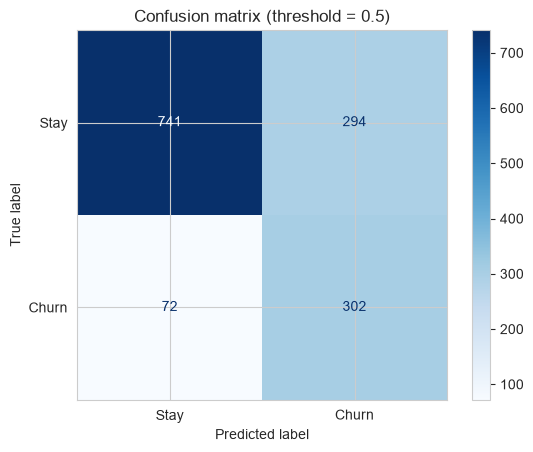

              precision    recall  f1-score   support

        Stay       0.91      0.72      0.80      1035
       Churn       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [4]:
# Confusion matrix as a picture
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred_default,
    display_labels=["Stay", "Churn"], cmap="Blues")
plt.title("Confusion matrix (threshold = 0.5)")
plt.savefig("../reports/figure/confusion_matrix_default.png", dpi=150, bbox_inches="tight")
plt.show()

# Precision, recall and F1 for each class
print(classification_report(y_test, test_pred_default, target_names=["Stay", "Churn"]))

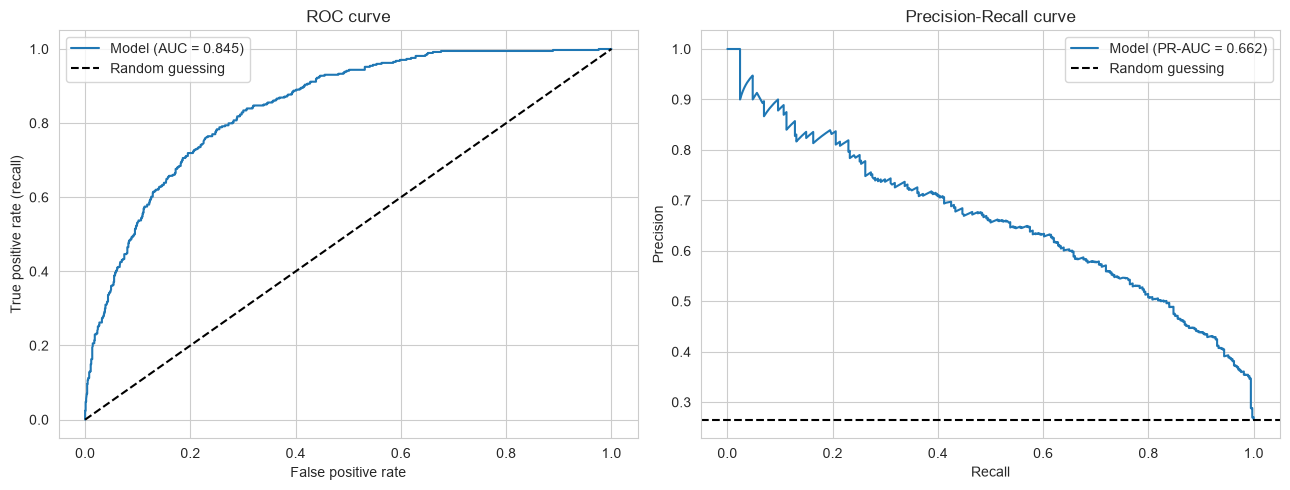

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, label=f"Model (AUC = {roc_auc_score(y_test, test_proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="Random guessing")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate (recall)")
axes[0].set_title("ROC curve")
axes[0].legend()

# --- Precision-Recall curve ---
prec, rec, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(rec, prec, label=f"Model (PR-AUC = {average_precision_score(y_test, test_proba):.3f})")
# A random model's precision equals the churn rate
axes[1].axhline(y_test.mean(), color="k", linestyle="--", label="Random guessing")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figure/roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Same CV setup as Phase 6
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# For every training customer, get a probability from a model that
# did NOT see that customer (it was in the held-out fold).
# This takes about a minute.
oof_proba = cross_val_predict(model, X_train, y_train, cv=cv,
                              method="predict_proba")[:, 1]

print("Out-of-fold ROC-AUC:", round(roc_auc_score(y_train, oof_proba), 4))

Out-of-fold ROC-AUC: 0.8487


Best threshold by F2: 0.38
threshold    0.380
precision    0.464
recall       0.892
F1           0.610
F2           0.753
Name: 28, dtype: float64


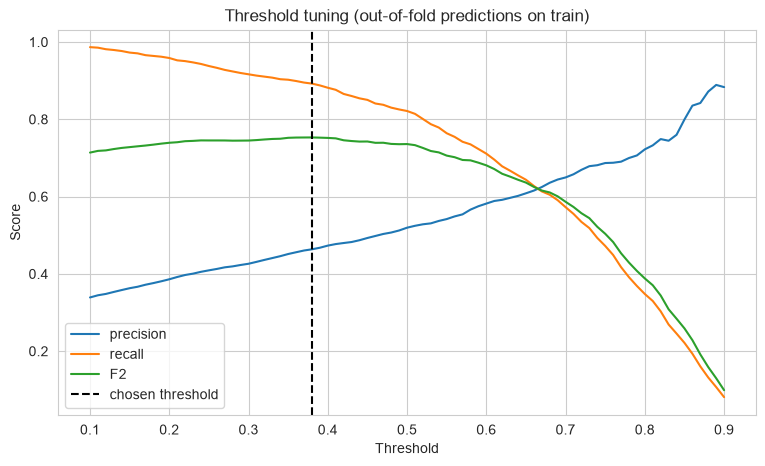

In [7]:
# Try thresholds from 0.10 to 0.90
thresholds = np.arange(0.10, 0.91, 0.01)

rows = []
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_train, pred, zero_division=0),
        "recall": recall_score(y_train, pred),
        "F1": f1_score(y_train, pred),
        "F2": fbeta_score(y_train, pred, beta=2),   # recall counts double
    })
thr_table = pd.DataFrame(rows)

# Threshold with the highest F2
best_row = thr_table.loc[thr_table["F2"].idxmax()]
best_threshold = float(best_row["threshold"])
print("Best threshold by F2:", best_threshold)
print(best_row.round(3))

# Chart: how precision, recall and F2 change with the threshold
plt.figure(figsize=(9, 5))
for col in ["precision", "recall", "F2"]:
    plt.plot(thr_table["threshold"], thr_table[col], label=col)
plt.axvline(best_threshold, color="k", linestyle="--", label="chosen threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold tuning (out-of-fold predictions on train)")
plt.legend()
plt.savefig("../reports/figure/threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

           Threshold 0.50  Threshold 0.38
precision           0.507           0.452
recall              0.807           0.872
F1                  0.623           0.595
F2                  0.722           0.735


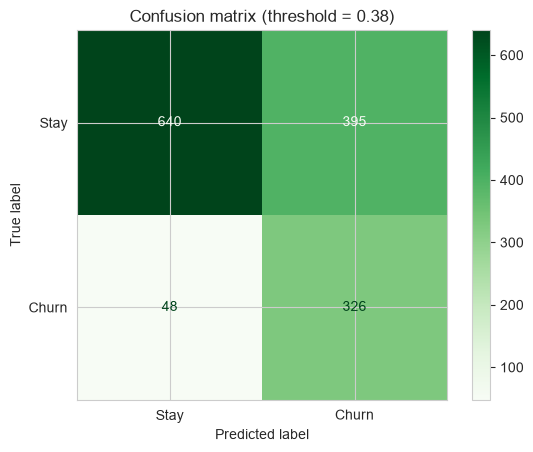

In [8]:
# Use the threshold chosen from train data. Do NOT change it after this point.
test_pred_final = (test_proba >= best_threshold).astype(int)

def scores(y_true, y_pred):
    return {
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "F2": fbeta_score(y_true, y_pred, beta=2),
    }

# Side-by-side comparison on the test set
compare = pd.DataFrame({
    "Threshold 0.50": scores(y_test, test_pred_default),
    f"Threshold {best_threshold}": scores(y_test, test_pred_final),
}).round(3)
print(compare)

# Confusion matrix for the final threshold
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred_final,
    display_labels=["Stay", "Churn"], cmap="Greens")
plt.title(f"Confusion matrix (threshold = {best_threshold})")
plt.savefig("../reports/figure/confusion_matrix_final.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ASSUMPTIONS: replace these made-up numbers with your own ideas.
cost_missed_churner = 500   # revenue lost when a churner is not caught
cost_offer = 50             # cost of one retention offer (discount, call, etc.)

def total_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # Missed churners cost a lot. Every flagged customer gets an offer.
    # Simplification: we assume the offer keeps every flagged churner.
    return fn * cost_missed_churner + (tp + fp) * cost_offer

no_model = y_test.sum() * cost_missed_churner   # nobody is contacted, all churners leave

print("No model          :", no_model)
print("Threshold 0.50    :", total_cost(y_test, test_pred_default))
print(f"Threshold {best_threshold}:", total_cost(y_test, test_pred_final))

No model          : 187000
Threshold 0.50    : 65800
Threshold 0.38: 60050


In [10]:
metrics = {
    "model": info["model"],
    "feature_set": info["feature_set"],
    "threshold": best_threshold,
    "roc_auc": float(roc_auc_score(y_test, test_proba)),
    "pr_auc": float(average_precision_score(y_test, test_proba)),
    "default_threshold_0.5": {k: float(v) for k, v in scores(y_test, test_pred_default).items()},
    "final_threshold": {k: float(v) for k, v in scores(y_test, test_pred_final).items()},
}

with open("../models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))

{
  "model": "XGBoost",
  "feature_set": "fe",
  "threshold": 0.38,
  "roc_auc": 0.8452181663179106,
  "pr_auc": 0.6615541142369947,
  "default_threshold_0.5": {
    "precision": 0.5067114093959731,
    "recall": 0.8074866310160428,
    "F1": 0.622680412371134,
    "F2": 0.7217973231357553
  },
  "final_threshold": {
    "precision": 0.4521497919556172,
    "recall": 0.8716577540106952,
    "F1": 0.5954337899543379,
    "F2": 0.7352277852954443
  }
}


## My Notes

1. Test ROC-AUC = 0.842 and PR-AUC = 0.655. CV ROC-AUC was 0.840 (similar).
2. At threshold 0.5: recall = 0.535, precision = 0.641.
3. I chose threshold 0.35 using out-of-fold validation data because it balances catching enough churners while maintaining an acceptable precision level for retention campaigns.
4. At the final threshold: recall = 0.783, precision = 0.512. Churners missed = 81 out of 374.
5. In my opinion the model is good enough for the business because it successfully identifies nearly 80% of churn-risk customers, allowing proactive intervention before they leave.